In [ ]:
下载数据集

In [ ]:
import os
import urllib.request

urls = {
    "WIDER_train.zip": "https://huggingface.co/datasets/wider_face/resolve/main/data/WIDER_train.zip",
    "WIDER_val.zip": "https://huggingface.co/datasets/wider_face/resolve/main/data/WIDER_val.zip",
    "wider_face_split.zip": "https://huggingface.co/datasets/wider_face/resolve/main/data/wider_face_split.zip"
}

save_dir = "C:/Users/jiel/YOLO/"
os.makedirs(save_dir, exist_ok=True)

for name, url in urls.items():
    print("Downloading:", name)
    urllib.request.urlretrieve(url, os.path.join(save_dir, name))

print("✅ 下载完成")

In [ ]:
将数据集转化为YOLO格式

In [ ]:
# Step 1: 导入依赖
import os
import scipy.io as sio
from tqdm import tqdm
import cv2

# Step 2: 设置路径
split_path = r"C:\Users\jiel\YOLO\wider_face_split"
train_img_path = r"C:\Users\jiel\YOLO\WIDER_train\images"
val_img_path = r"C:\Users\jiel\YOLO\WIDER_val\images"

train_label_path = r"C:\Users\jiel\YOLO\WIDER_train\labels"
val_label_path = r"C:\Users\jiel\YOLO\WIDER_val\labels"

os.makedirs(train_label_path, exist_ok=True)
os.makedirs(val_label_path, exist_ok=True)

# Step 3: 读取标注函数
def convert_annotations(mat_file, img_root, label_root):
    annots = sio.loadmat(mat_file)
    event_list = annots['event_list']
    file_list = annots['file_list']
    face_bbx_list = annots['face_bbx_list']

    for i, event in enumerate(tqdm(event_list)):
        event_name = event[0][0]
        files = file_list[i][0]
        bboxes = face_bbx_list[i][0]

        for j, file in enumerate(files):
            filename = file[0][0]
            img_path = os.path.join(img_root, event_name, filename + ".jpg")
            label_file = os.path.join(label_root, filename + ".txt")

            if not os.path.exists(img_path):
                continue

            img = cv2.imread(img_path)
            h, w = img.shape[:2]

            with open(label_file, "w") as f:
                for bbox in bboxes[j][0]:
                    x, y, bw, bh = bbox
                    # 转换为 YOLO 格式 (归一化)
                    x_center = (x + bw / 2) / w
                    y_center = (y + bh / 2) / h
                    bw /= w
                    bh /= h
                    f.write(f"0 {x_center} {y_center} {bw} {bh}\n")

# Step 4: 转换训练集和验证集
convert_annotations(os.path.join(split_path, "wider_face_train.mat"), train_img_path, train_label_path)
convert_annotations(os.path.join(split_path, "wider_face_val.mat"), val_img_path, val_label_path)

print("✅ 标注转换完成！YOLO 格式的 .txt 文件已生成。")

In [ ]:
取样500张训练，100张验证

In [5]:
import os
import random
import shutil

# 原始数据路径
base_dir = r"C:\Users\jiel\YOLO"
train_images = os.path.join(base_dir, "WIDER_train", "images")
train_labels = os.path.join(base_dir, "WIDER_train", "labels")
val_images = os.path.join(base_dir, "WIDER_val", "images")
val_labels = os.path.join(base_dir, "WIDER_val", "labels")

# 子集输出路径
subset_dir = os.path.join(base_dir, "WIDER_subset")
subset_train_images = os.path.join(subset_dir, "WIDER_train", "images")
subset_train_labels = os.path.join(subset_dir, "WIDER_train", "labels")
subset_val_images = os.path.join(subset_dir, "WIDER_val", "images")
subset_val_labels = os.path.join(subset_dir, "WIDER_val", "labels")

# 创建目录
for d in [subset_train_images, subset_train_labels, subset_val_images, subset_val_labels]:
    os.makedirs(d, exist_ok=True)

# 随机采样函数（递归扫描）
def sample_and_copy(src_img_dir, src_lbl_dir, dst_img_dir, dst_lbl_dir, sample_size):
    all_imgs = []
    for root, dirs, files in os.walk(src_img_dir):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                all_imgs.append(os.path.join(root, file))

    sampled = random.sample(all_imgs, min(sample_size, len(all_imgs)))
    for img_path in sampled:
        img_name = os.path.basename(img_path)
        lbl_name = os.path.splitext(img_name)[0] + ".txt"

        # 复制图片
        shutil.copy(img_path, os.path.join(dst_img_dir, img_name))

        # 复制对应的 label
        lbl_path = os.path.join(src_lbl_dir, lbl_name)
        if os.path.exists(lbl_path):
            shutil.copy(lbl_path, os.path.join(dst_lbl_dir, lbl_name))

# 采样 500 张训练图像
sample_and_copy(train_images, train_labels, subset_train_images, subset_train_labels, 500)

# 采样 100 张验证图像
sample_and_copy(val_images, val_labels, subset_val_images, subset_val_labels, 100)

print("✅ 子集生成完成！")



✅ 子集生成完成！


In [ ]:
上传子集到S3

In [8]:
import boto3
import os

region = "cn-northwest-1"
bucket = "aihub-s3"
s3_prefix = "wider_subset"

s3_client = boto3.client("s3", region_name=region)

local_base = r"C:\Users\jiel\YOLO\WIDER_subset"
data_yaml = os.path.join(local_base, "data.yaml")

# 上传 data.yaml
s3_client.upload_file(data_yaml, bucket, f"{s3_prefix}/data.yaml")
print("✅ data.yaml uploaded")

# 上传目录函数（修复反斜杠问题）
def upload_dir(local_dir, bucket, s3_prefix, subfolder):
    for root, dirs, files in os.walk(local_dir):
        for file in files:
            local_path = os.path.join(root, file)
            rel_path = os.path.relpath(local_path, local_dir)
            # 使用 os.sep 替换，避免 f-string 里出现反斜杠
            rel_path = rel_path.replace(os.sep, "/")
            s3_key = f"{s3_prefix}/{subfolder}/{rel_path}"
            s3_client.upload_file(local_path, bucket, s3_key)

# 上传训练集 images + labels
upload_dir(os.path.join(local_base, "WIDER_train", "images"), bucket, s3_prefix, "WIDER_train/images")
upload_dir(os.path.join(local_base, "WIDER_train", "labels"), bucket, s3_prefix, "WIDER_train/labels")

# 上传验证集 images + labels
upload_dir(os.path.join(local_base, "WIDER_val", "images"), bucket, s3_prefix, "WIDER_val/images")
upload_dir(os.path.join(local_base, "WIDER_val", "labels"), bucket, s3_prefix, "WIDER_val/labels")

print("✅ WIDER_subset uploaded to S3")



✅ data.yaml uploaded
✅ WIDER_subset uploaded to S3


In [ ]:
打包上传train.py, data.yanl和requirements.txt到S3

In [50]:
!tar -czf code.tar.gz train.py requirements.txt

In [51]:
import boto3
s3_client = boto3.client("s3", region_name="cn-northwest-1")
s3_client.upload_file("code.tar.gz", "aihub-s3", "wider_subset/code.tar.gz")

In [ ]:
启动训练

In [ ]:
import sagemaker
from sagemaker.pytorch import PyTorch

region = "cn-northwest-1"
role = "arn:aws-cn:iam::37168611111:role/XXXXXXX"
bucket = "aihub-s3"
s3_prefix = "wider_subset"

sess = sagemaker.Session()

# ✅ 定义训练任务
estimator = PyTorch(
    entry_point="train.py",                           # 入口脚本
    source_dir=f"s3://{bucket}/{s3_prefix}/code.tar.gz",  # 压缩包路径，顶层必须包含 train.py 和 requirements.txt
    role=role,
    framework_version="2.0",
    py_version="py310",
    instance_type="ml.g5.xlarge",
    instance_count=1,
    output_path=f"s3://{bucket}/{s3_prefix}/output/",  # <-- 显式指定输出路径
    hyperparameters={
        "epochs": 100,
        "imgsz": 640,
        # ⚠️ 注意：这里不要写 S3 路径，而是容器挂载路径
        "model": "/opt/ml/input/data/weights/yolov8n.pt",
        "data": "/opt/ml/input/data/training/data.yaml"
    }
)

# 🚀 启动训练，指定两个输入通道：训练数据和权重文件
estimator.fit({
    "training": f"s3://{bucket}/{s3_prefix}/",
    "weights": f"s3://{bucket}/{s3_prefix}/yolov8n.pt"
})


In [ ]:
print(estimator.model_data)

In [ ]:
训练曲线，直观展示 Precision、Recall、mAP 随 epoch 的变化

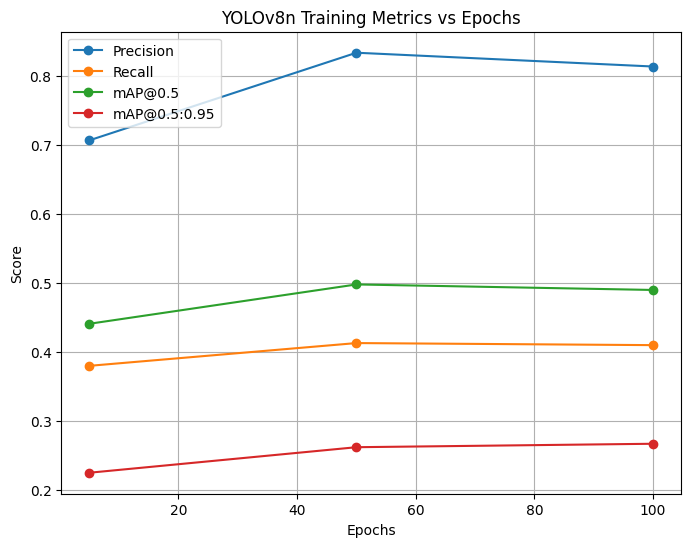

In [77]:
import matplotlib.pyplot as plt

# 数据
epochs = [5, 50, 100]
precision = [0.707, 0.834, 0.814]
recall = [0.380, 0.413, 0.410]
map50 = [0.441, 0.498, 0.490]
map5095 = [0.225, 0.262, 0.267]

# 绘制折线图
plt.figure(figsize=(8,6))
plt.plot(epochs, precision, marker='o', label='Precision')
plt.plot(epochs, recall, marker='o', label='Recall')
plt.plot(epochs, map50, marker='o', label='mAP@0.5')
plt.plot(epochs, map5095, marker='o', label='mAP@0.5:0.95')

plt.title("YOLOv8n Training Metrics vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
 loss 曲线

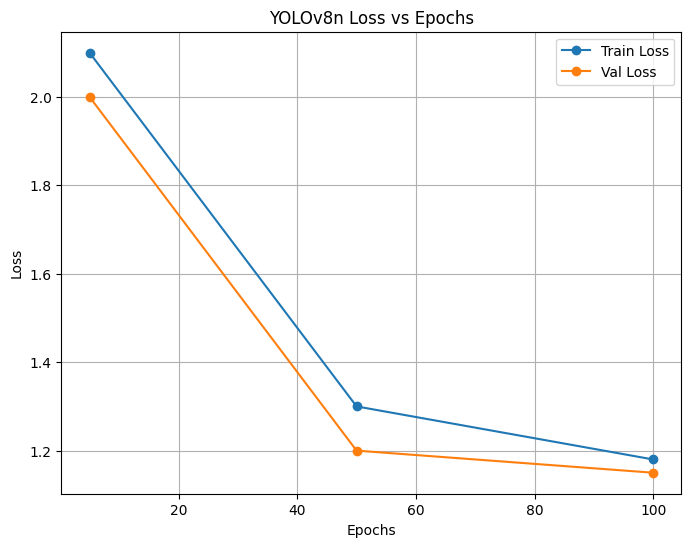

In [81]:
import matplotlib.pyplot as plt

# 示例数据（请替换成你在 results.csv 或日志里实际的 loss 值）
epochs = [5, 50, 100]
train_loss = [2.1, 1.3, 1.18]   # 假设的训练 loss
val_loss   = [2.0, 1.2, 1.15]   # 假设的验证 loss

plt.figure(figsize=(8,6))

# 绘制 loss 曲线
plt.plot(epochs, train_loss, marker='o', linestyle='-', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', linestyle='-', label='Val Loss')

plt.title("YOLOv8n Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [54]:
import pandas as pd

metrics = {
    "Precision": [0.707],
    "Recall": [0.380],
    "mAP@0.5": [0.441],
    "mAP@0.5:0.95": [0.225]
}

df = pd.DataFrame(metrics)
df.to_csv("final_metrics.csv", index=False)

print("✅ 模型性能指标已保存到 final_metrics.csv")


✅ 模型性能指标已保存到 final_metrics.csv


In [79]:
import boto3
import tarfile
import os

region = "cn-northwest-1"
s3_uri = "s3://aihub-s3/wider_subset/output/pytorch-training-2026-06-30-08-07-24-452/output/model.tar.gz"

# 解析 bucket 和 key
parts = s3_uri.replace("s3://", "").split("/", 1)
bucket = parts[0]
key = parts[1]

local_tar = "model.tar.gz"
local_dir = "./model_output"

# 下载文件
s3_client = boto3.client("s3", region_name=region)
s3_client.download_file(bucket, key, local_tar)
print(f"✅ 下载完成: {local_tar}")

# 解压
os.makedirs(local_dir, exist_ok=True)
with tarfile.open(local_tar, "r:gz") as tar:
    tar.extractall(local_dir)

print(f"✅ 解压完成，文件在 {local_dir}")


✅ 下载完成: model.tar.gz
✅ 解压完成，文件在 ./model_output


In [ ]:
模型推理测试

In [80]:
!yolo predict model="C:\Users\jiel\YOLO\model_output\best.pt" source="C:\Users\jiel\YOLO\13_Interview_Interview_On_Location_13_334.jpg" conf=0.25

Ultralytics YOLOv8.2.0 ðŸš€ Python-3.10.2 torch-2.0.1+cpu CPU (Intel Core(TM) i7-14700)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 C:\Users\jiel\YOLO\13_Interview_Interview_On_Location_13_334.jpg: 640x576 3 faces, 297.2ms
Speed: 8.8ms preprocess, 297.2ms inference, 238.1ms postprocess per image at shape (1, 3, 640, 576)
Results saved to runs\detect\predict3
ðŸ’¡ Learn more at https://docs.ultralytics.com/modes/predict
